# Phase 3 — Churn Prediction

Trains on the feature table built in phase 2. Three models:

1. **Logistic regression** — interpretable baseline
2. **XGBoost, all features** — expected to score near-perfectly because of the
   deterministic rules in the synthetic data (monthly contract, age 60+)
3. **XGBoost, behavioral features only** — the honest model. Drops demographics and
   contract so it has to learn from usage, support calls, and payment behavior

Then: SHAP explanations, threshold-as-business-decision analysis, and scores written
back to postgres for the dashboard.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, classification_report)

from xgboost import XGBClassifier
import shap

plt.rcParams["figure.figsize"] = (9, 4.5)
root = Path.cwd() if (Path.cwd() / "sql").exists() else Path.cwd().parent
eng = create_engine(os.environ.get("CHURN_DB_URL", "postgresql+psycopg2:///churn"))

In [2]:
ft = pd.read_parquet(root / "data" / "features.parquet")
print(ft.shape)

ids = ft.customer_id
y = ft.churned
X = ft.drop(columns=["customer_id", "churned"])

# stratified split, hold 20% out. random_state pinned so results are reproducible
X_tr, X_te, y_tr, y_te, id_tr, id_te = train_test_split(
    X, y, ids, test_size=0.2, stratify=y, random_state=42)
print("train:", X_tr.shape, " test:", X_te.shape, " churn rate:", round(y.mean(), 3))

(440832, 17)
train: (352665, 15)  test: (88167, 15)  churn rate: 0.567


## Model 1 — logistic regression baseline

ROC-AUC: 0.9537
PR-AUC:  0.97


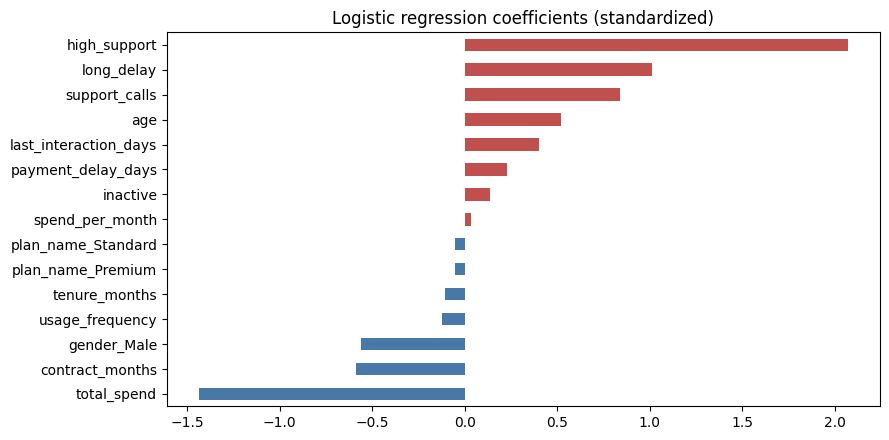

In [3]:
scaler = StandardScaler()
Xs_tr = scaler.fit_transform(X_tr)
Xs_te = scaler.transform(X_te)

lr = LogisticRegression(max_iter=2000, class_weight="balanced")
lr.fit(Xs_tr, y_tr)
p_lr = lr.predict_proba(Xs_te)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_te, p_lr), 4))
print("PR-AUC: ", round(average_precision_score(y_te, p_lr), 4))

# coefficients = the interview talking points
coefs = pd.Series(lr.coef_[0], index=X.columns).sort_values()
coefs.plot(kind="barh", color=np.where(coefs > 0, "#c0504d", "#4878a8"))
plt.title("Logistic regression coefficients (standardized)")
plt.tight_layout()
plt.show()

## Model 2 — XGBoost, all features

This is the score-chasing model. Expect ~0.99+ because the data has hard rules.

In [4]:
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                    eval_metric="aucpr", n_jobs=-1, random_state=42)
xgb.fit(X_tr, y_tr)
p_xgb = xgb.predict_proba(X_te)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_te, p_xgb), 4))
print("PR-AUC: ", round(average_precision_score(y_te, p_xgb), 4))

ROC-AUC: 1.0
PR-AUC:  1.0


## Model 3 — behavioral features only

Drop everything a deterministic rule could lean on (contract, age, gender, plan).
What's left is what a retention team can actually act on.

In [5]:
behav = ["tenure_months", "total_spend", "usage_frequency", "support_calls",
         "payment_delay_days", "last_interaction_days", "high_support",
         "long_delay", "spend_per_month", "inactive"]

xgb_b = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                      eval_metric="aucpr", n_jobs=-1, random_state=42)
xgb_b.fit(X_tr[behav], y_tr)
p_b = xgb_b.predict_proba(X_te[behav])[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_te, p_b), 4))
print("PR-AUC: ", round(average_precision_score(y_te, p_b), 4))
# takeaway: compare against model 2. the gap = how much signal was just
# the synthetic rules vs actual behavior

ROC-AUC: 0.9612
PR-AUC:  0.978


## SHAP — why customers churn

On the behavioral model, since that's the one with a story. Sampled for speed.

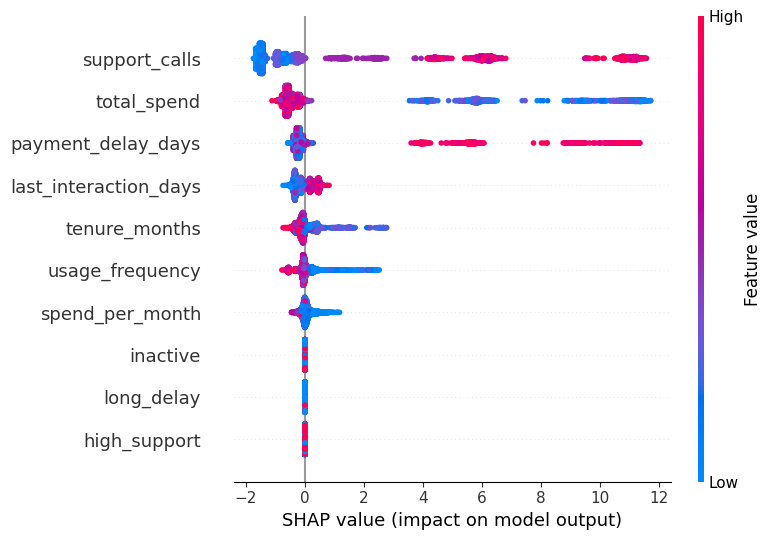

In [6]:
samp = X_te[behav].sample(min(5000, len(X_te)), random_state=42)
expl = shap.TreeExplainer(xgb_b)
sv = expl.shap_values(samp)
shap.summary_plot(sv, samp, show=False)
plt.tight_layout()
plt.show()
# takeaway: support_calls and payment_delay should dominate, matching the EDA

## Threshold as a business decision

Accuracy at 0.5 is meaningless here. The real question: at what predicted probability
do you spend money on a retention offer?

Toy cost model — tune these to taste:
- retention offer costs **$30** per customer flagged
- offer saves the customer 40% of the time
- a lost customer costs their **annual spend** (using avg spend as a stand-in)

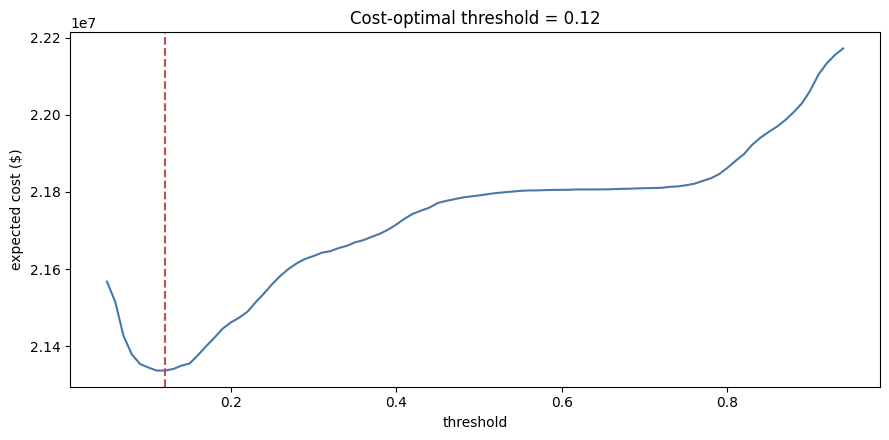

at t=0.12: flag 75% of customers
              precision    recall  f1-score   support

      stayed       0.93      0.54      0.68     38167
     churned       0.73      0.97      0.83     50000

    accuracy                           0.78     88167
   macro avg       0.83      0.75      0.76     88167
weighted avg       0.82      0.78      0.77     88167



In [7]:
offer_cost = 30
save_rate = 0.4
cust_value = float(ft.total_spend.mean())

prec, rec, thr = precision_recall_curve(y_te, p_b)

# expected cost at each threshold: offers sent + churners missed
costs = []
for t in np.arange(0.05, 0.95, 0.01):
    flag = p_b >= t
    n_flag = flag.sum()
    # churners we flagged might be saved; churners we missed walk
    caught = (flag & (y_te == 1)).sum()
    missed = ((~flag) & (y_te == 1)).sum()
    cost = n_flag * offer_cost + (missed + caught * (1 - save_rate)) * cust_value
    costs.append((t, cost))
cc = pd.DataFrame(costs, columns=["threshold", "expected_cost"])

best = cc.loc[cc.expected_cost.idxmin()]
ax = cc.plot(x="threshold", y="expected_cost", legend=False, color="#4878a8")
ax.axvline(best.threshold, color="#c0504d", ls="--")
ax.set_ylabel("expected cost ($)")
ax.set_title(f"Cost-optimal threshold = {best.threshold:.2f}")
plt.tight_layout()
plt.show()

flag = p_b >= best.threshold
print(f"at t={best.threshold:.2f}: flag {flag.mean()*100:.0f}% of customers")
print(classification_report(y_te, flag, target_names=["stayed", "churned"]))

## Persist — models to disk, scores to postgres for the dashboard

In [8]:
(root / "models").mkdir(exist_ok=True)
joblib.dump(xgb, root / "models" / "xgb_full.joblib")
joblib.dump(xgb_b, root / "models" / "xgb_behavioral.joblib")
joblib.dump({"scaler": scaler, "model": lr}, root / "models" / "logreg.joblib")

# score EVERY customer with the behavioral model so the dashboard can show
# predicted risk next to actuals
scores = pd.DataFrame({
    "customer_id": ids,
    "churn_prob": xgb_b.predict_proba(X[behav])[:, 1].round(4),
})
scores["risk_band"] = pd.cut(scores.churn_prob, [0, .3, .6, .85, 1],
                             labels=["low", "medium", "high", "critical"])
scores.to_sql("model_scores", eng, if_exists="replace", index=False, chunksize=20000)
print("wrote", len(scores), "rows to model_scores")
scores.risk_band.value_counts()

wrote 440832 rows to model_scores


risk_band
critical    216405
low         207092
medium       13233
high          4102
Name: count, dtype: int64

## Writeup notes

For the README / interview:
- report all three scores side by side, lead with the *behavioral* one
- the full-feature model scoring ~1.0 is evidence the data is synthetic, not evidence of skill --
  say that out loud, it reads as senior
- the threshold section is the differentiator: most churn projects stop at AUC,
  this one prices the decision